# Benchmark Models (LevHAR)

In [1]:
import pandas as pd 
import numpy as np
file_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data Sets/RV_total.csv"
df = pd.read_csv(file_path)

# Convert "Date" column to datetime 
df["Date"] = pd.to_datetime(df["Date"], utc=True).dt.tz_convert("Europe/Berlin")
df = df.sort_values("Date").set_index("Date")

df.tail()

,Open,Close,log_open,log_close,r_overnight,RV_intra,RV_overnight,RV_total,RQ,r_daily,log_RV_total,log_RV_intra
Date,,,,,,,,,,,,
2020-08-03 00:00:00+02:00,3186.02,3253.20,8.066528,8.087394,-0.001132,0.000108,0.000001,0.000109,1.898579e-08,0.019734,-9.121878,-9.133686
2020-08-04 00:00:00+02:00,3270.71,3251.94,8.092762,8.087007,0.005368,0.000129,0.000029,0.000158,2.613017e-08,-0.000387,-8.755823,-8.957822
2020-08-05 00:00:00+02:00,3274.81,3267.21,8.094015,8.091692,0.007008,0.000068,0.000049,0.000117,7.450015e-09,0.004685,-9.056151,-9.602531
2020-08-06 00:00:00+02:00,3257.99,3244.07,8.088866,8.084584,-0.002826,0.000109,0.000008,0.000117,1.545187e-08,-0.007108,-9.052878,-9.123543
2020-08-07 00:00:00+02:00,3235.30,3248.01,8.081877,8.085798,-0.002707,0.000089,0.000007,0.000097,3.748493e-08,0.001214,-9.243673,-9.322462


## 1.3 LevHAR Model

**Economic intuition behind the LevHAR model:**

The standard HAR model captures volatility persistence across horizons (daily, weekly, and monthly). However, it ignores an important empirical fact: Negative returns today increases tomorrow's volatility more than positive returns of the same magnitude. This is called the leverage effect.

There are two main explanations: 
1) **Financial leverage mechanism:** A price drop increases the firm's leverage ratio, which implies that equity becomes risker and thus results in higher volatility.
2) **Volatility feedback / risk premium channel:** Negative shocks increase required returns, thus raising conditional volatility

Note that we will only incorporate the leverage effect on yesterday's return because the leverage effect is fundamentally a short-run shock mechanism: 
* A negative shock today immediately increases tomorrow's conditional variance
* The effect decays through the HAR structure naturally

**LevHAR Model:**
$$
RV_t
= \beta_0
+ \beta_d \, RV_{t-1}
+ \beta_w \, RV_{t-1}^{(w)}
+ \beta_m \, RV_{t-1}^{(m)}
+ \gamma \, r_{t-1}
+ \varepsilon_t
$$

In [5]:
# Safety procedure
df_levHAR = df.sort_index().copy()

rv = df_levHAR["RV_total"]

# Regressors available at time t
df_levHAR["RV_d"] = rv
df_levHAR["RV_w"] = rv.rolling(window=5).mean()
df_levHAR["RV_m"] = rv.rolling(window=22).mean()

# Leverage term available at time t
df_levHAR["r_d"] = df_levHAR["r_daily"]

# Target: next day's RV
df_levHAR["RV_target"] = rv.shift(-1)

In [7]:
# Drop NA to define usable sample
df_levHAR = df_levHAR.dropna(subset=["RV_d", "RV_w", "RV_m", "r_d", "RV_target"])

print("First usable date:", df_levHAR.index.min())
print("Last usable date:", df_levHAR.index.max())
print("Number of usable observations:", len(df_levHAR))

First usable date: 1998-03-31 00:00:00+02:00
Last usable date: 2020-08-06 00:00:00+02:00
Number of usable observations: 5689


**Deciding on train, validation, and test splits:**
* Train = 1998 - 2012 (Train includes dot-com + GFC → rich volatility regimes) *~60–65% train*
* Validation = 2013 - 2015 (Validation includes Euro crisis aftershocks) *~15% validation*
* Test = 2016 - 2020 (Test includes calm + COVID shock) *~20–25% test*

In [10]:
# Define split dates
train_end = "2012-12-31"
val_end   = "2015-12-31"

# Chronological split
df_train = df_levHAR.loc[:train_end]
df_val   = df_levHAR.loc[train_end:val_end]
df_test  = df_levHAR.loc[val_end:]

# Remove boundary overlap (same logic as before)
df_val  = df_val.iloc[1:]
df_test = df_test.iloc[1:]

# Diagnostics
print("Train observations:", len(df_train))
print("Validation observations:", len(df_val))
print("Test observations:", len(df_test))

print("\nTrain period:", df_train.index.min(), "to", df_train.index.max())
print("Validation period:", df_val.index.min(), "to", df_val.index.max())
print("Test period:", df_test.index.min(), "to", df_test.index.max())

Train observations: 3745
Validation observations: 768
Test observations: 1176

Train period: 1998-03-31 00:00:00+02:00 to 2012-12-31 00:00:00+01:00
Validation period: 2013-01-02 00:00:00+01:00 to 2015-12-31 00:00:00+01:00
Test period: 2016-01-04 00:00:00+01:00 to 2020-08-06 00:00:00+02:00


#### LevHAR on Training set

In [13]:
import statsmodels.api as sm

# Regressors and target (training only)
X_train = df_train[["RV_d", "RV_w", "RV_m", "r_d"]]
y_train = df_train["RV_target"]

# Add intercept
X_train = sm.add_constant(X_train)

# Estimate OLS
levhar_model = sm.OLS(y_train, X_train).fit(cov_type="HC1")

print(levhar_model.summary())

                            OLS Regression Results                            
Dep. Variable:              RV_target   R-squared:                       0.597
Model:                            OLS   Adj. R-squared:                  0.596
Method:                 Least Squares   F-statistic:                     101.3
Date:                Thu, 19 Feb 2026   Prob (F-statistic):           5.73e-82
Time:                        13:33:00   Log-Likelihood:                 27284.
No. Observations:                3745   AIC:                        -5.456e+04
Df Residuals:                    3740   BIC:                        -5.453e+04
Df Model:                           4                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.599e-05   7.09e-06      2.254      0.0

**Estimated Model:**
$$
RV_{t+1}
= \beta_0
+ 0.312 \, RV_t
+ 0.417 \, RV_t^{(w)}
+ 0.177 \, RV_t^{(m)}
- 0.0024 \, r_t
$$


Slighlty higher R-squared of **60%** relative to level HAR model **(58%)**, implying that the leverage effect does add some explanatory power to the model. Note that leverage effect term $\gamma$ is negative and statistically significant. This implies that if today's return is negative, tomorrow's conditional variance will increase. This confirms the leverage effect for the EURO STOXX 50. 

In [17]:
from tqdm import tqdm

# Evaluation window = validation + test
df_eval = pd.concat([df_val, df_test])

predictions_rv = []
actuals_rv = []
dates = []

for current_date in tqdm(df_eval.index):

    # Expanding window: all rows strictly before current_date
    df_expanding = df_levHAR.loc[:current_date].iloc[:-1]

    # Regressors + target
    X = df_expanding[["RV_d", "RV_w", "RV_m", "r_d"]]
    y = df_expanding["RV_target"]

    X = sm.add_constant(X, has_constant="add")
    model = sm.OLS(y, X).fit()

    # Forecast row (1-row DataFrame)
    X_fore = df_levHAR.loc[[current_date], ["RV_d", "RV_w", "RV_m", "r_d"]]
    X_fore = sm.add_constant(X_fore, has_constant="add")
    X_fore = X_fore.reindex(columns=X.columns)

    # Forecast in RV units
    rv_forecast = float(model.predict(X_fore).iloc[0])

    # Actual RV_{t+1}
    rv_actual = float(df_levHAR.loc[current_date, "RV_target"])

    predictions_rv.append(rv_forecast)
    actuals_rv.append(rv_actual)
    dates.append(current_date)

df_forecast_levHAR = pd.DataFrame(
    {"Forecast": predictions_rv, "Actual": actuals_rv},
    index=dates
)

print(df_forecast_levHAR.head())
print("\nForecast df shape:", df_forecast_levHAR.shape)

100%|██████████████████████████████████████| 1944/1944 [00:03<00:00, 587.35it/s]

                           Forecast    Actual
2013-01-02 00:00:00+01:00  0.000051  0.000027
2013-01-03 00:00:00+01:00  0.000060  0.000032
2013-01-04 00:00:00+01:00  0.000057  0.000028
2013-01-07 00:00:00+01:00  0.000068  0.000027
2013-01-08 00:00:00+01:00  0.000061  0.000030

Forecast df shape: (1944, 2)


In [19]:
# Define validation and test ranges (same as before)
val_start, val_end = df_val.index.min(), df_val.index.max()
test_start, test_end = df_test.index.min(), df_test.index.max()

# Split the LevHAR forecast dataframe
df_forecast_val = df_forecast_levHAR.loc[val_start:val_end]
df_forecast_test = df_forecast_levHAR.loc[test_start:test_end]

# Compute MSE
mse_val = np.mean((df_forecast_val["Actual"] - df_forecast_val["Forecast"])**2)
mse_test = np.mean((df_forecast_test["Actual"] - df_forecast_test["Forecast"])**2)

# Print in identical structure
print(f"Validation period: {val_start} to {val_end} | n = {len(df_forecast_val)}")
print(f"Test period: {test_start} to {test_end} | n = {len(df_forecast_test)}")

print("\nValidation MSE:", mse_val)
print("Test MSE:", mse_test)

Validation period: 2013-01-02 00:00:00+01:00 to 2015-12-31 00:00:00+01:00 | n = 768
Test period: 2016-01-04 00:00:00+01:00 to 2020-08-06 00:00:00+02:00 | n = 1176

Validation MSE: 1.1260821683178245e-08
Test MSE: 2.232862860250399e-08


Test MSE is double the size of Validation MSE, which is economically inuitive as the test period includes the 2018 volatility spike and the 2020 COVID shock. Volatility forecasting models struggle more during crisis regimes.

Hom much better HAR is than simply forecasting historical mean: 
$$
R^2_{\text{OOS}}
= 1
- \frac{\sum \left( RV_{t+1} - \widehat{RV}_{t+1} \right)^2}
       {\sum \left( RV_{t+1} - \overline{RV} \right)^2}
$$

#### Plotting performance during entire Test period

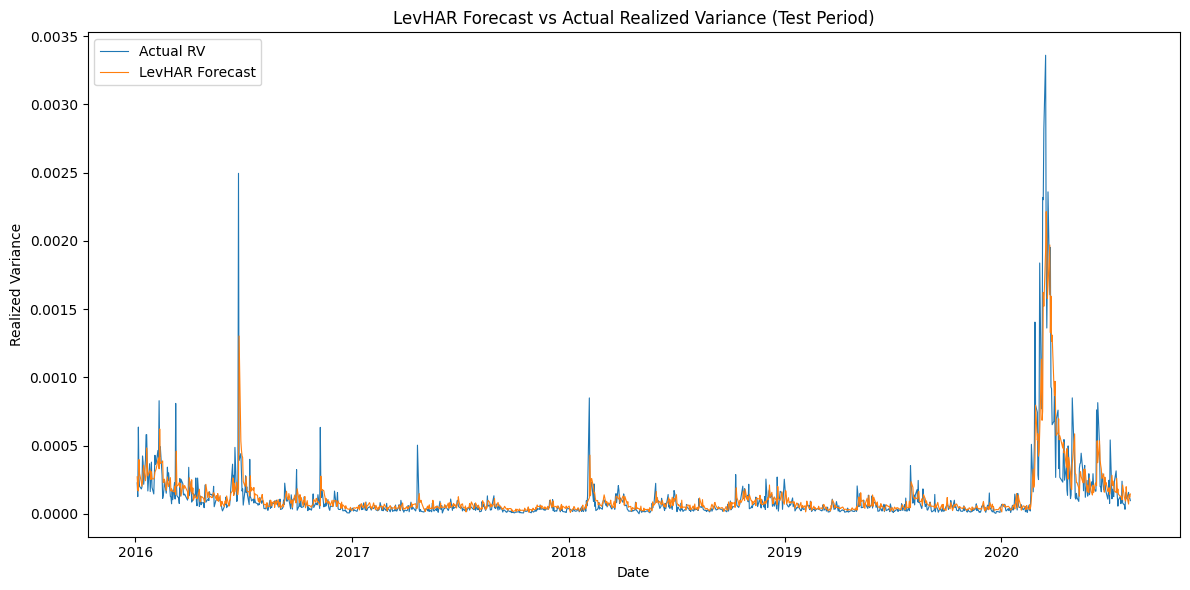

In [23]:
import matplotlib.pyplot as plt

# Use test-period forecasts from LevHAR
df_plot = df_forecast_levHAR.loc[
    df_test.index.min():df_test.index.max()
].copy()

plt.figure(figsize=(12,6))

plt.plot(df_plot.index, df_plot["Actual"],
         label="Actual RV",
         linewidth=0.8)

plt.plot(df_plot.index, df_plot["Forecast"],
         label="LevHAR Forecast",
         linewidth=0.8)

plt.title("LevHAR Forecast vs Actual Realized Variance (Test Period)")
plt.xlabel("Date")
plt.ylabel("Realized Variance")

plt.legend()
plt.tight_layout()
plt.show()

In [25]:
# Benchmark: mean RV from TRAINING sample only (LEVELS)
mean_train = df_train["RV_target"].mean()

# Define validation and test ranges
val_start, val_end = df_val.index.min(), df_val.index.max()
test_start, test_end = df_test.index.min(), df_test.index.max()

# Split LevHAR forecast dataframe
df_forecast_val = df_forecast_levHAR.loc[val_start:val_end]
df_forecast_test = df_forecast_levHAR.loc[test_start:test_end]

# --- Validation ---
sse_val = np.sum((df_forecast_val["Actual"] - df_forecast_val["Forecast"])**2)
sse_val_bench = np.sum((df_forecast_val["Actual"] - mean_train)**2)

r2_oos_val = 1 - (sse_val / sse_val_bench)

# --- Test ---
sse_test = np.sum((df_forecast_test["Actual"] - df_forecast_test["Forecast"])**2)
sse_test_bench = np.sum((df_forecast_test["Actual"] - mean_train)**2)

r2_oos_test = 1 - (sse_test / sse_test_bench)

print("Out-of-sample R^2 (Validation, LevHAR):", r2_oos_val)
print("Out-of-sample R^2 (Test, LevHAR):", r2_oos_test)

Out-of-sample R^2 (Validation, LevHAR): 0.4127999314493055
Out-of-sample R^2 (Test, LevHAR): 0.6660581119923633


* $R^2_{\text{OOS}} > 0$ --> model beats mean forecast
* $R^2_{\text{OOS}} = 0$ --> same as mean forecast
* $R^2_{\text{OOS}} < 0$ --> wore than mean forecast

## Performance during COVID

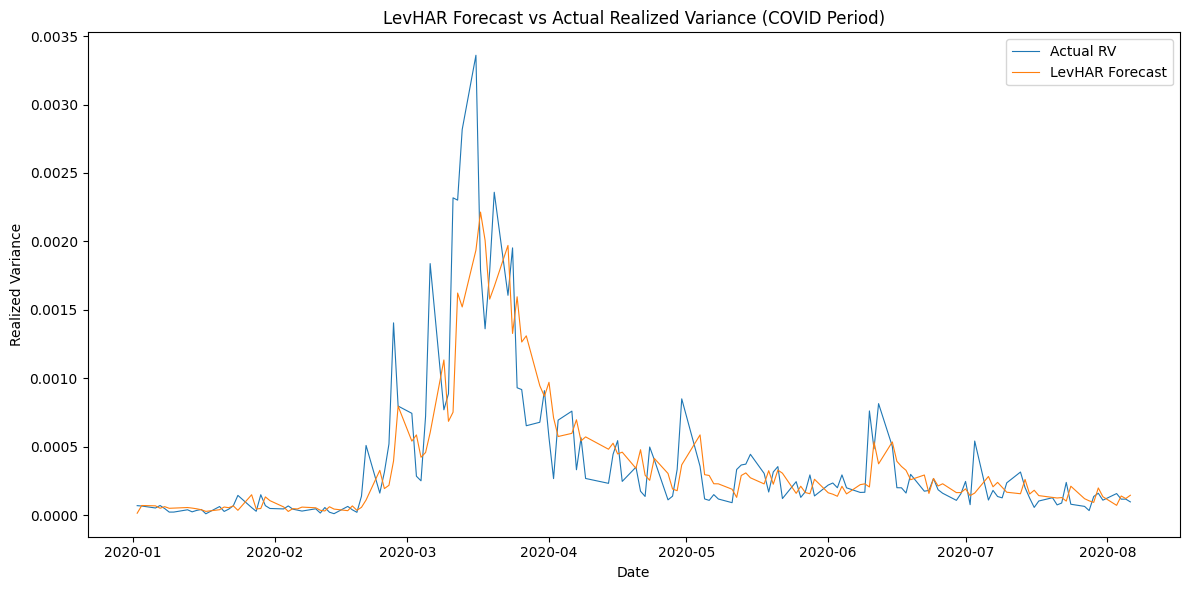

In [28]:
# Select COVID period from LevHAR forecasts
df_covid = df_forecast_levHAR.loc["2020-01-01":].copy()

plt.figure(figsize=(12,6))

plt.plot(df_covid.index, df_covid["Actual"],
         label="Actual RV",
         linewidth=0.8)

plt.plot(df_covid.index, df_covid["Forecast"],
         label="LevHAR Forecast",
         linewidth=0.8)

plt.title("LevHAR Forecast vs Actual Realized Variance (COVID Period)")
plt.xlabel("Date")
plt.ylabel("Realized Variance")

plt.legend()
plt.tight_layout()
plt.show()